## **CW Radar exercise for Radar Study Course**

**Project info:** <br>
1) Define system use case
2) Perform system level calculations
3) Implement system
4) Test system

**The final system should be able to:**<br>
- Compute FFT of received signal
- See doppler shift and calculate the corresponding velocities
- Determine whether the target is moving toward or away from the receiver


--------------
#### **1) How CW radar work**
Generated complex baseband signal is:
$$
x_{t,bb}(t) = A_t
$$

This gives the complex passband signal after upconversion as:
$$
x_{t,pb} = A_t e^{j 2\pi f_c t}
$$

The Real transmitted signal is then:
$$
x_t(t) = \Re \left[ x_{t,bb}(t) e^{j 2\pi f_c t}\right] = A_t \cos(2 \pi f_c t)
$$

Received signal is then:
$$
x_r(t) = A_r e^{j 2\pi \left( f_c \pm f_d \right)t}
$$

The doppler shift $f_d$ of target can be used to calculate the radial velocity as:
$$
v_r = \frac{\lambda f_d}{2} \tag{1}
$$

-----------------

#### **2) System Level Calculations**

**Targets:** <br>
Cars <br>

**Velocities:** <br>
Expected car velocities
$$v_{car} \in [10, 200]~km/h \\ \therefore v_{car} \in [2.8, 56]~m/s$$

**CW frequency:** <br>
From the antenna measurements, the antenna is best matched at: <br>
$f_{CW} = 2.175 ~\text{GHz}$ <br>
$\lambda_{CW} = \frac{3 \cdot 10^8}{2.175 \cdot 10^9} = 0.1379 ~m \approx 13.8~cm$

**Doppler frequency:** <br>
From Eq. (1), the expected range of the doppler frequencies corresponding to the velocities in $v_{car}$ are:
$$
f_d \in \left[ \frac{2 v_{car,min}}{\lambda_{CW}}, \frac{2 v_{car,max}}{\lambda_{CW}} \right] Hz \\
\Rightarrow f_d \in \left[40.6,812 \right] Hz
$$

**Dwell time / FFT size**
We know that 
$$
\Delta f = \frac{1}{T_{dwell}} \tag{2}
$$

We need the FFT resolution to be able to show the smallest Doppler shifts:
$$\Delta f \leq f_{d,min} \\ \therefore \Delta f \leq 40.6 ~ Hz$$

to obtain this, we know from Eq. (2), that:
$$
T_{dwell} = \frac{1}{\Delta f} = \frac{1}{40.6} \approx 25~ms
$$

Example dwell times and corresponding FFT frequency resolutions:
$$
T_{dwell} = 25~ms \Rightarrow \Delta f = 40~Hz \\
T_{dwell} = 50~ms \Rightarrow \Delta f = 20~Hz \\
T_{dwell} = 100~ms \Rightarrow \Delta f = 10~Hz \\
T_{dwell} = 200~ms \Rightarrow \Delta f = 5~Hz
$$

**Sampling Frequency** <br>
The highest doppler frequency is 812 Hz and therefore we need at least:
$$
f_s \geq 2 f_{d,max} = 2 \cdot 812 = 1624 ~S/s
$$

10x oversampling gives a sampling frequency of:
$$
f_s = 10 \cdot 1624 = 16240 ~S/s
$$

**FFT Size** <br>
The required FFT size is then:
$$
N_{FFT} = f_s T_{dwell} = 16240 \cdot 200~ms = 3248
$$

With the nearest power of two being:
$$
\log_2(3248) = \lceil 11.665 \rceil = 12
$$

Therefore, the FFT size becomes:
$$
N_{FFT} = 2^{12} = 4096
$$

-------------------------

#### **Final System Parameters**
Since the required FFT length was calculated as:
$$
N_{FFT} = 4096,
$$

the final system parameters become:

$$
f_s = 16240~\text{S/s}
$$

$$
T_{dwell} = \frac{N_{FFT}}{f_s} = \frac{4096}{16240} \approx 0.252~\text{s} = 252~\text{ms}
$$

$$
\Delta f = \frac{1}{T_{dwell}} \approx \frac{1}{0.252} \approx 3.97~\text{Hz}
$$

$$
f_d \in [40.6, 812]~\text{Hz}
$$

The corresponding velocity resolution is given by
$$
\Delta v = \frac{\lambda}{2} \Delta f \approx 0.27~\text{m/s} \approx 1.0~\text{km/h}
$$
-------------------

#### **Reflections on system parameters**
- It would be nice to have a better velocity resolution e.g. of $0.1 km/h = 0.0278 m/s$ however, since dwell time is dependent on velocity resolution and wavelength, the only way to improve this is to:
1) Keep current dwell time $(200~ms)$ and increase frequency to approx. 27 GHz (impossible for Pluto)
2) Keep current frequency and increase dwell time to approx 2.5 s (bad for fast measurements)

-------------------

#### **3) Hardware specs**

##### **Antenna Measurements**
**S11 from 1 GHz to 3.5 GHz**
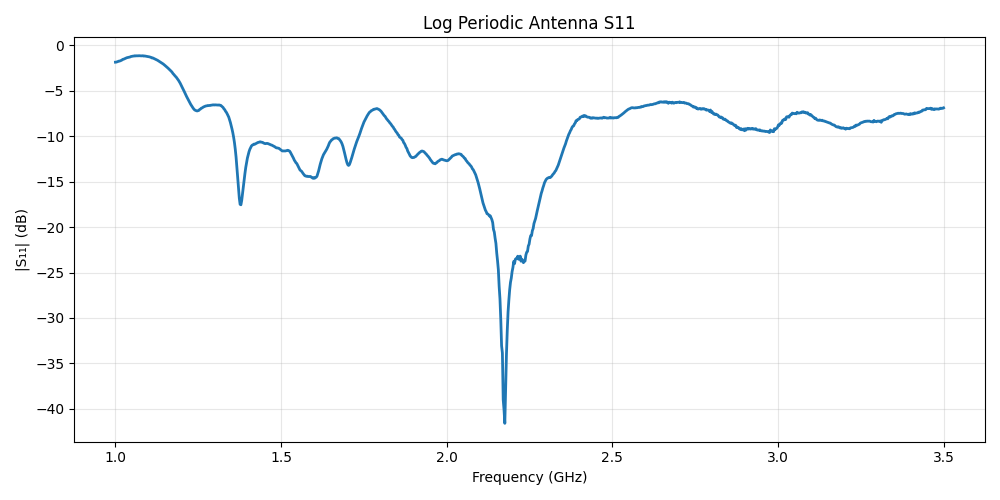

**S11 from 2.1 GHz to 2.3 GHz**
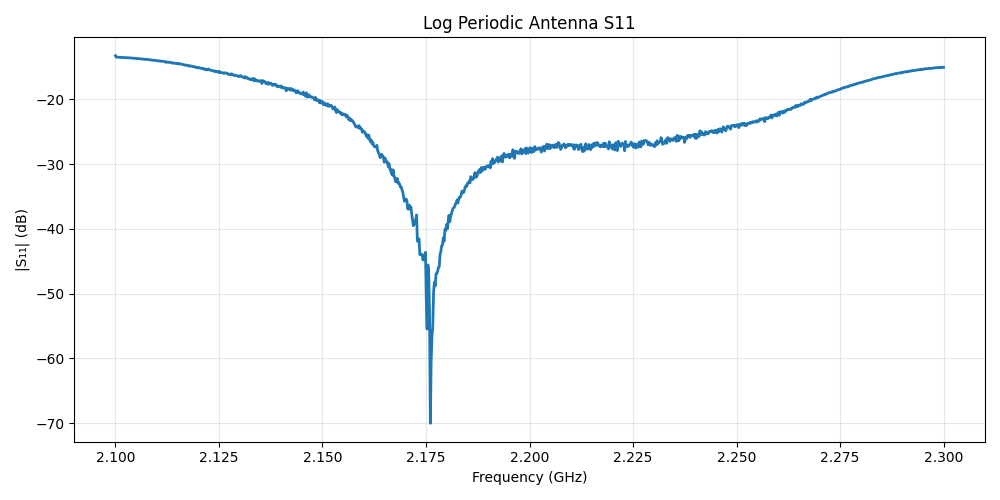

**Gain estimate**
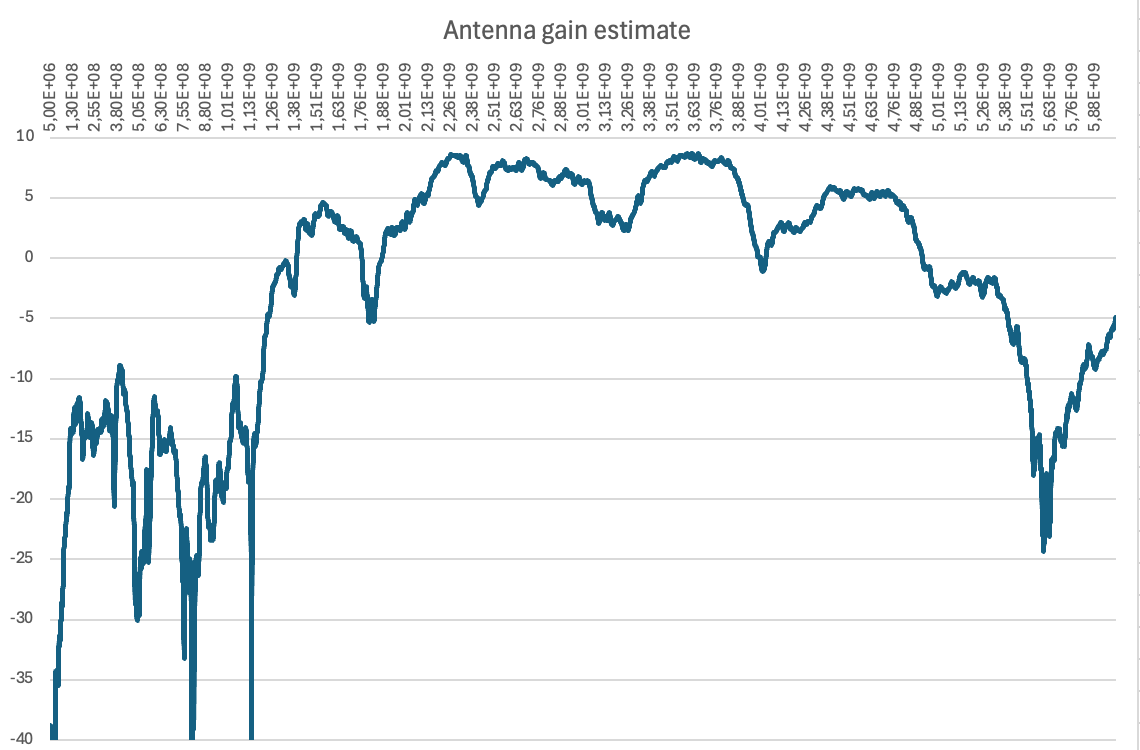

**Conclusion** <br>
Clearly the antenna is resonant around 2.175 GHz with a gain around 7 dBi.

##### **ADALM PLUTO**
**TX power** <br>
The measured Tx power of the Adalm Pluto was $-3.4~dBm = 457 \mu W$.

**Noise Floor** <br>
The measured noise floor of the Adalm Pluto was $-96.5~dBm = 223.87 \cdot 10^{-15} W$.

A minimum detection SNR of approximately 10 dB is assumed. Classical radar detection theory shows that an SNR of about 13 dB yields a detection probability of 90% with a false alarm rate of 10^{-6} for a nonfluctuating target [1]. In practical radar systems, additional losses and non-idealities typically increase the required SNR to approximately 10–15 dB [1], [2]. <br>
From this we conclude, that the minimum detectable signal is $\text{MDS} = S_{min} = \text{Noise Floor} + 13~dB = -83.5~dBm = 4.47 p W$ 

**Radar cross section of car** <br>
The radar cross section of a car is estimated to be around $10 m^2$.

**Range** <br>
The range of the CW radar setup is then calculated to be:
$$
R_{max} = R_{\max} = \sqrt[4]{\frac{P_t \cdot G^2 \cdot \lambda^2 \cdot \sigma}{(4\pi)^3 \cdot S_{min}}} = \sqrt[4]{\frac{(4.57 \times 10^{-4}) \cdot (5.01)^2 \cdot (0.138)^2 \cdot 10}{(4\pi)^3 \cdot (4.47 \times 10^{-12})}} = 22.3 m
$$

<p>
[1] M. I. Skolnik, <i>Introduction to Radar Systems</i>, 3rd ed. New York: McGraw-Hill, 2001. <br>
[2] M. A. Richards, <i>Fundamentals of Radar Signal Processing</i>, 2nd ed. New York: McGraw-Hill, 2014.
</p>

---------------